# tblastn Strict-Clean Validation

Goal: validate tblastn lifting on strict-clean annotated records, then separate raw failures into likely tool errors vs likely validation artifacts.

This notebook stops at the failure overview. Detailed FMD/PRRS case-by-case adjudication can be added after reviewing these outputs.

## Flow

1. Run tblastn on strict-clean records.
2. Compare predictions with annotated truth.
3. Report raw exact accuracy: name, start, and end all match.
4. Break down non-exact cases into three hypothesis buckets:
   - `likely_validation_artifact`: ref/query annotation or truth-model issue.
   - `likely_tool_error`: likely a real lifting mistake.
   - `manual_review`: not enough evidence yet.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from app.validation._shared.validation_utils import *

TIER = 'strict_clean'
BASE_DIR = Path.cwd()
if not (BASE_DIR / 'inputs').exists() and (BASE_DIR / 'tiers' / TIER / 'inputs').exists():
    BASE_DIR = BASE_DIR / 'tiers' / TIER

INPUT_DIR = BASE_DIR / 'inputs'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

RAW_COLORS = {
    'exact_match': '#2f7d4f',
    'coord_only': '#75b66b',
    'failed_coord_or_name': '#c44e52',
}

BUCKET_COLORS = {
    'likely_validation_artifact': '#4c78a8',
    'likely_tool_error': '#c44e52',
    'manual_review': '#d6a13d',
}

REVIEW_COLUMNS = [
    'virus', 'record_id', 'ref_name', 'pred_name', 'truth_name', 'best_overlap_name',
    'pred_start', 'pred_end', 'truth_start', 'truth_end', 'delta_start', 'delta_end',
    'status', 'coverage', 'identity', 'iou', 'best_iou', 'failure_mode',
    'adjudicated_bucket', 'adjudication_note', 'count_as_tool_error',
]


## Inputs

These are the strict-clean records used for validation. A record is kept only when truth features resolve to canonical names and do not contain duplicate canonical names.

In [2]:
manifest = pd.read_csv(INPUT_DIR / 'manifest.tsv', sep='	')
tier_input_summary = pd.read_csv(INPUT_DIR / 'summary.tsv', sep='	')
tier_input_summary

,virus,reason,records,kept
0,FMD,kept_clean,96,96
1,FMD,duplicate_canonical_names,2,0
2,FMD,no_truth_features,2,0
3,PRRS,kept_clean,95,95
4,PRRS,noncanonical_truth:ignored,4,0
5,PRRS,duplicate_canonical_names,1,0


## Run tblastn And Compare To Truth

This forces tblastn for every query record, then compares each predicted feature to the query's annotated truth feature with the same canonical name.

In [3]:
DATASETS = [
    ('PRRS', DATA / 'PRRS_ref_test.gb', INPUT_DIR / 'PRRS_records.gb'),
    ('FMD', DATA / 'FMD_ref_test.gb', INPUT_DIR / 'FMD_records.gb'),
]

frames = []
summaries = []
for virus, ref_path, query_path in DATASETS:
    records = load_genbank_records(query_path)
    print(f'{virus}: {len(records)} strict-clean records')
    if not records:
        continue
    df, summary = run_tblastn_against_truth(
        virus_label=virus,
        ref_path=ref_path,
        query_path=query_path,
        output_dir=OUTPUT_DIR / virus.lower(),
        progress=True,
    )
    if not df.empty:
        frames.append(df)
    if not summary.empty:
        summaries.append(summary)

tblastn_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
tblastn_summary = pd.concat(summaries, ignore_index=True) if summaries else pd.DataFrame()

tblastn_df.to_csv(OUTPUT_DIR / 'tblastn_vs_truth.tsv', sep='	', index=False)
tblastn_summary.to_csv(OUTPUT_DIR / 'tblastn_summary.tsv', sep='	', index=False)
tblastn_summary

PRRS: 95 strict-clean records


tblastn  PRRS:   0%|          | 0/95 [00:00<?, ?rec/s]

FMD: 96 strict-clean records


tblastn  FMD:   0%|          | 0/96 [00:00<?, ?rec/s]

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,PRRS,tblastn,855,593,685,0.8297,69.36,80.12
1,FMD,tblastn,1152,1088,1131,0.9937,94.44,98.18


## Raw Accuracy

This is the unadjusted validation score.

- `exact_match`: predicted name, start, and end exactly match truth.
- `coord_only`: predicted name matches and IoU >= 0.90, but at least one boundary differs.
- `failed_coord_or_name`: name is missing/mismatched or coordinates are not close enough.

In [4]:
raw_accuracy = (
    tblastn_df.groupby('virus')
    .agg(
        total=('pred_name', 'size'),
        exact_match=('exact_match', 'sum'),
        coord_correct=('coord_correct', 'sum'),
    )
    .reset_index()
)
raw_accuracy['coord_only'] = raw_accuracy['coord_correct'] - raw_accuracy['exact_match']
raw_accuracy['failed_coord_or_name'] = raw_accuracy['total'] - raw_accuracy['coord_correct']
raw_accuracy['exact_pct'] = (raw_accuracy['exact_match'] / raw_accuracy['total'] * 100).round(2)
raw_accuracy['coord_pct'] = (raw_accuracy['coord_correct'] / raw_accuracy['total'] * 100).round(2)
raw_accuracy['failed_pct'] = (raw_accuracy['failed_coord_or_name'] / raw_accuracy['total'] * 100).round(2)
raw_accuracy.to_csv(OUTPUT_DIR / 'strict_clean_raw_accuracy.tsv', sep='	', index=False)
raw_accuracy

,virus,total,exact_match,coord_correct,coord_only,failed_coord_or_name,exact_pct,coord_pct,failed_pct
0,FMD,1152,1088,1131,43,21,94.44,98.18,1.82
1,PRRS,855,593,685,92,170,69.36,80.12,19.88


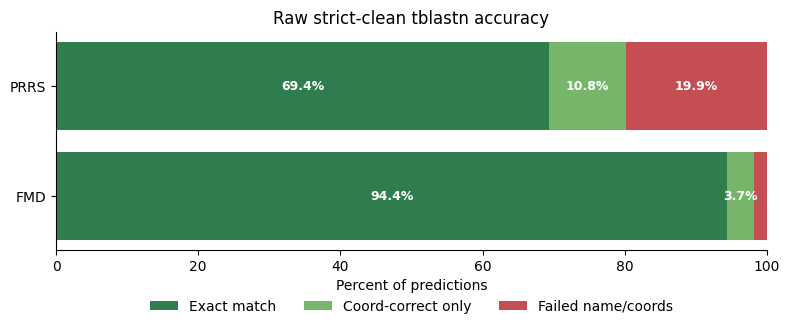

In [5]:
plot_df = raw_accuracy.set_index('virus')[['exact_match', 'coord_only', 'failed_coord_or_name']]
plot_pct = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 3.6))
left = pd.Series(0.0, index=plot_pct.index)
labels = {
    'exact_match': 'Exact match',
    'coord_only': 'Coord-correct only',
    'failed_coord_or_name': 'Failed name/coords',
}
for col in ['exact_match', 'coord_only', 'failed_coord_or_name']:
    vals = plot_pct[col]
    bars = ax.barh(plot_pct.index, vals, left=left, color=RAW_COLORS[col], label=labels[col])
    for bar, value, start in zip(bars, vals, left):
        if value >= 3:
            ax.text(start + value / 2, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%',
                    ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('Percent of predictions')
ax.set_title('Raw strict-clean tblastn accuracy')
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.35), frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'strict_clean_raw_accuracy.png', dpi=180, bbox_inches='tight')


## Failure Breakdown Overview

Raw failures mix together true tool errors and validation artifacts. This first-pass adjudication is rule-based and intentionally conservative. It is meant to create a review queue, not final biological truth.

In [15]:
def adjudicate_failure(row):
    pred = row.get('pred_name')
    truth = row.get('truth_name')
    best = row.get('best_overlap_name')
    mode = row.get('failure_mode')

    if bool(row.get('exact_match')):
        return ('exact_match', 'Exact name/start/end match.', False)

    if bool(row.get('coord_correct')):
        return (
            'manual_review',
            'Name matches and IoU >= 0.90, but boundary differs. Need ref-vs-query boundary check.',
            None,
        )

    if pd.isna(truth) and pred in {'ORF2b', 'VP3', 'VP4'}:
        return (
            'likely_validation_artifact',
            'Predicted feature has no same-name truth annotation in this strict-clean query set.',
            False,
        )

    if pred in {'ORF1a', 'ORF1b'} and best == 'ORF1ab':
        return (
            'likely_validation_artifact',
            'Ref/query granularity mismatch: split ORF1a/ORF1b prediction overlaps ORF1ab truth.',
            False,
        )

    if mode in {'Wrong coords', 'Not lifted'}:
        return (
            'likely_tool_error',
            f'{mode}: same-name truth exists but tblastn did not recover the correct region.',
            True,
        )

    if mode in {'Alias/name gap', 'Possible overlap', 'Not in truth'}:
        return (
            'manual_review',
            f'{mode}: overlaps or naming need case-level review before assigning blame.',
            None,
        )

    return (
        'manual_review',
        f'{mode}: not adjudicated by current rules.',
        None,
    )

failures = tblastn_df[~tblastn_df['exact_match']].copy()
if not failures.empty:
    failures['delta_start'] = failures['pred_start'] - failures['truth_start']
    failures['delta_end'] = failures['pred_end'] - failures['truth_end']
    adjudicated = failures.apply(adjudicate_failure, axis=1, result_type='expand')
    adjudicated.columns = ['adjudicated_bucket', 'adjudication_note', 'count_as_tool_error']
    failures = pd.concat([failures, adjudicated], axis=1)
else:
    failures['delta_start'] = []
    failures['delta_end'] = []
    failures['adjudicated_bucket'] = []
    failures['adjudication_note'] = []
    failures['count_as_tool_error'] = []

failures.to_csv(OUTPUT_DIR / 'strict_clean_failure_adjudication.tsv', sep='	', index=False)
failures.head(20)

,virus,record_id,method,pred_name,source_name,pred_start,pred_end,strand,status,coverage,...,iou,name_match,coord_correct,exact_match,failure_mode,delta_start,delta_end,adjudicated_bucket,adjudication_note,count_as_tool_error
1,PRRS,AF184212.1,tblastn,ORF1b,None,7795.0,12180.0,+,invalid_boundaries,1.0000,...,0.9986,True,True,False,Boundary offset,6.0,0.0,manual_review,"Name matches and IoU >= 0.90, but boundary dif...",None
3,PRRS,AF184212.1,tblastn,ORF2b,None,12187.0,12408.0,+,ok,1.0000,...,0.0000,False,False,False,Possible overlap,NaN,NaN,likely_validation_artifact,Predicted feature has no same-name truth annot...,False
10,PRRS,AF159149.1,tblastn,ORF1b,None,7662.0,12047.0,+,invalid_boundaries,1.0000,...,0.9986,True,True,False,Boundary offset,6.0,0.0,manual_review,"Name matches and IoU >= 0.90, but boundary dif...",None
12,PRRS,AF159149.1,tblastn,ORF2b,None,12054.0,12275.0,+,ok,1.0000,...,0.0000,False,False,False,Possible overlap,NaN,NaN,likely_validation_artifact,Predicted feature has no same-name truth annot...,False
19,PRRS,AF325691.1,tblastn,ORF1b,None,7664.0,12049.0,+,invalid_boundaries,1.0000,...,0.9986,True,True,False,Boundary offset,6.0,0.0,manual_review,"Name matches and IoU >= 0.90, but boundary dif...",None
21,PRRS,AF325691.1,tblastn,ORF2b,None,12056.0,12277.0,+,ok,1.0000,...,0.0000,False,False,False,Possible overlap,NaN,NaN,likely_validation_artifact,Predicted feature has no same-name truth annot...,False
28,PRRS,AY032626.1,tblastn,ORF1b,None,7687.0,12072.0,+,invalid_boundaries,1.0000,...,0.9973,True,True,False,Boundary offset,-12.0,0.0,manual_review,"Name matches and IoU >= 0.90, but boundary dif...",None
30,PRRS,AY032626.1,tblastn,ORF2b,None,12079.0,12300.0,+,ok,1.0000,...,0.0000,False,False,False,Possible overlap,NaN,NaN,likely_validation_artifact,Predicted feature has no same-name truth annot...,False
37,PRRS,AF494042.1,tblastn,ORF1b,None,7670.0,12055.0,+,invalid_boundaries,1.0000,...,0.9993,True,True,False,Boundary offset,-3.0,0.0,manual_review,"Name matches and IoU >= 0.90, but boundary dif...",None
39,PRRS,AF494042.1,tblastn,ORF2b,None,12062.0,12283.0,+,ok,1.0000,...,0.0000,False,False,False,Possible overlap,NaN,NaN,likely_validation_artifact,Predicted feature has no same-name truth annot...,False


In [16]:
bucket_summary = (
    failures.groupby(['virus', 'adjudicated_bucket'])
    .size()
    .reset_index(name='failed_cases')
    if not failures.empty else pd.DataFrame(columns=['virus', 'adjudicated_bucket', 'failed_cases'])
)
if not bucket_summary.empty:
    totals = tblastn_df.groupby('virus').size().rename('total_predictions')
    failed_totals = failures.groupby('virus').size().rename('non_exact_cases')
    bucket_summary = bucket_summary.merge(totals, on='virus').merge(failed_totals, on='virus')
    bucket_summary['pct_of_all_predictions'] = (bucket_summary['failed_cases'] / bucket_summary['total_predictions'] * 100).round(2)
    bucket_summary['pct_of_non_exact'] = (bucket_summary['failed_cases'] / bucket_summary['non_exact_cases'] * 100).round(2)

bucket_summary.to_csv(OUTPUT_DIR / 'strict_clean_failure_bucket_summary.tsv', sep='	', index=False)
bucket_summary

,virus,adjudicated_bucket,failed_cases,total_predictions,non_exact_cases,pct_of_all_predictions,pct_of_non_exact
0,FMD,likely_tool_error,18,1152,64,1.56,28.12
1,FMD,likely_validation_artifact,2,1152,64,0.17,3.12
2,FMD,manual_review,44,1152,64,3.82,68.75
3,PRRS,likely_tool_error,28,855,262,3.27,10.69
4,PRRS,likely_validation_artifact,140,855,262,16.37,53.44
5,PRRS,manual_review,94,855,262,10.99,35.88


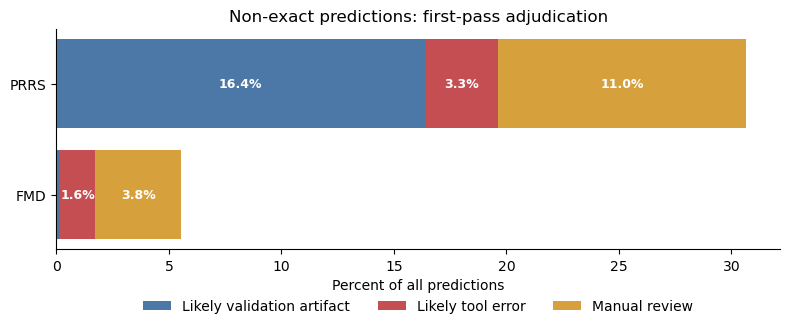

In [17]:
if not bucket_summary.empty:
    bucket_order = ['likely_validation_artifact', 'likely_tool_error', 'manual_review']
    plot_df = (
        bucket_summary.pivot_table(index='virus', columns='adjudicated_bucket', values='pct_of_all_predictions', fill_value=0)
        .reindex(columns=bucket_order, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(8, 3.6))
    left = pd.Series(0.0, index=plot_df.index)
    label_map = {
        'likely_validation_artifact': 'Likely validation artifact',
        'likely_tool_error': 'Likely tool error',
        'manual_review': 'Manual review',
    }
    for bucket in bucket_order:
        vals = plot_df[bucket]
        bars = ax.barh(plot_df.index, vals, left=left, color=BUCKET_COLORS[bucket], label=label_map[bucket])
        for bar, value, start in zip(bars, vals, left):
            if value >= 1.5:
                ax.text(start + value / 2, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%',
                        ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        left += vals

    ax.set_xlabel('Percent of all predictions')
    ax.set_title('Non-exact predictions: first-pass adjudication')
    ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.35), frameon=False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'strict_clean_failure_bucket_overview.png', dpi=180, bbox_inches='tight')


In [18]:
adjudicated_accuracy = raw_accuracy.copy()
if not bucket_summary.empty:
    tool_errors = (
        bucket_summary[bucket_summary['adjudicated_bucket'] == 'likely_tool_error']
        .set_index('virus')['failed_cases']
    )
    manual = (
        bucket_summary[bucket_summary['adjudicated_bucket'] == 'manual_review']
        .set_index('virus')['failed_cases']
    )
else:
    tool_errors = pd.Series(dtype=float)
    manual = pd.Series(dtype=float)

adjudicated_accuracy['likely_tool_errors'] = adjudicated_accuracy['virus'].map(tool_errors).fillna(0).astype(int)
adjudicated_accuracy['manual_review_cases'] = adjudicated_accuracy['virus'].map(manual).fillna(0).astype(int)
adjudicated_accuracy['likely_tool_error_pct'] = (adjudicated_accuracy['likely_tool_errors'] / adjudicated_accuracy['total'] * 100).round(2)
adjudicated_accuracy['best_case_tool_accuracy_pct'] = (100 - adjudicated_accuracy['likely_tool_error_pct']).round(2)
adjudicated_accuracy['worst_case_tool_accuracy_pct'] = (
    100 - ((adjudicated_accuracy['likely_tool_errors'] + adjudicated_accuracy['manual_review_cases']) / adjudicated_accuracy['total'] * 100)
).round(2)

adjudicated_accuracy.to_csv(OUTPUT_DIR / 'strict_clean_adjudicated_accuracy_overview.tsv', sep='	', index=False)
adjudicated_accuracy

,virus,total,exact_match,coord_correct,coord_only,failed_coord_or_name,exact_pct,coord_pct,failed_pct,likely_tool_errors,manual_review_cases,likely_tool_error_pct,best_case_tool_accuracy_pct,worst_case_tool_accuracy_pct
0,FMD,1152,1088,1131,43,21,94.44,98.18,1.82,18,44,1.56,98.44,94.62
1,PRRS,855,593,685,92,170,69.36,80.12,19.88,28,94,3.27,96.73,85.73


## FMD Failure Breakdown

This section starts from the **reference annotation model**, then compares each FMD failure against both the reference and the query truth.

The key question is not only "did prediction differ from truth?" but:

- did tblastn reproduce the reference feature length/boundary?
- does the query truth use a different boundary convention?
- or did tblastn/rescue produce a coordinate that matches neither ref nor truth?

### FMD Reference Model

The table below describes the FMD reference features that tblastn uses as templates. If a prediction length matches this model but differs from query truth, the failure may be a ref/query annotation disagreement rather than a tool error.

In [23]:
fmd_bundle = load_reference_bundle(DATA / 'FMD_ref_test.gb')
fmd_ref_model = pd.DataFrame([
    {
        'ref_name': feature['name'],
        'ref_start': feature['start'],
        'ref_end': feature['end'],
        'ref_len': feature['end'] - feature['start'] + 1,
        'ref_strand': feature.get('strand', '+'),
    }
    for feature in fmd_bundle['features']
])
fmd_ref_model.to_csv(OUTPUT_DIR / 'fmd_reference_model.tsv', sep='	', index=False)
fmd_ref_model

,ref_name,ref_start,ref_end,ref_len,ref_strand
0,Lpro,1184,1786,603,+
1,VP4,1787,2041,255,+
2,VP2,2042,2695,654,+
3,VP3,2696,3355,660,+
4,VP1,3356,3988,633,+
5,2A,3989,4042,54,+
6,2B,4043,4504,462,+
7,2C,4505,5458,954,+
8,3A,5459,5917,459,+
9,3B,5918,6130,213,+


### FMD Failure Evidence

Each non-exact FMD case is enriched with reference length, predicted length, truth length, and length deltas.

Interpretation shortcut:

- `pred_minus_ref_len = 0` and `truth_minus_ref_len != 0`: prediction follows ref; query truth differs.
- `truth_minus_ref_len = 0` and `pred_minus_ref_len != 0`: truth follows ref; prediction differs.
- both differ: manual review.

In [24]:
def _format_delta(series):
    values = pd.to_numeric(series, errors='coerce').dropna()
    if values.empty:
        return ''
    unique = sorted(values.unique())
    if len(unique) <= 5:
        return ', '.join(str(int(v)) if float(v).is_integer() else f'{v:g}' for v in unique)
    return f'median {values.median():.0f}; range {values.min():.0f}..{values.max():.0f}'


def _top_value(series):
    counts = series.dropna().astype(str).value_counts()
    return counts.index[0] if not counts.empty else ''


def _length_bucket(row):
    pred_ref = row.get('pred_minus_ref_len')
    truth_ref = row.get('truth_minus_ref_len')
    mode = row.get('failure_mode')

    if pd.isna(row.get('pred_len')):
        return 'not_lifted'
    if pd.isna(row.get('truth_len')):
        return 'truth_absent'
    if pred_ref == 0 and truth_ref != 0:
        return 'prediction_matches_ref_query_truth_differs'
    if truth_ref == 0 and pred_ref != 0:
        return 'prediction_differs_ref_and_truth'
    if pred_ref == 0 and truth_ref == 0:
        return 'same_length_boundary_shift'
    if mode == 'Boundary offset':
        return 'boundary_shift_mixed_length'
    return 'manual_review'


def _fmd_case_bucket(row):
    length_bucket = row.get('fmd_length_bucket')
    feature = row.get('ref_name')
    mode = row.get('failure_mode')

    if length_bucket in {'prediction_matches_ref_query_truth_differs', 'same_length_boundary_shift'}:
        return 'likely_validation_artifact'
    if length_bucket == 'truth_absent':
        return 'likely_validation_artifact'
    if length_bucket == 'not_lifted':
        return 'likely_tool_error'
    if feature == '3A' and row.get('delta_start') == 0 and row.get('delta_end') == -111:
        return 'likely_tool_error'
    if mode == 'Wrong coords' and length_bucket == 'prediction_differs_ref_and_truth':
        return 'likely_tool_error'
    return 'manual_review'


def _fmd_case_note(row):
    feature = row.get('ref_name')
    length_bucket = row.get('fmd_length_bucket')
    ds = row.get('delta_start')
    de = row.get('delta_end')

    if length_bucket == 'prediction_matches_ref_query_truth_differs':
        return 'Prediction length matches ref; query truth uses a different feature length/boundary.'
    if length_bucket == 'same_length_boundary_shift':
        return 'Ref, prediction, and truth have same length but shifted coordinates; likely annotation boundary convention difference.'
    if length_bucket == 'truth_absent':
        return 'No same-name truth feature in query annotation.'
    if length_bucket == 'not_lifted':
        return 'tblastn found no usable hit for this reference feature.'
    if feature == '3A' and ds == 0 and de == -111:
        return 'Start matches truth but C-terminus is 111 bp short; likely tool/HSP/rescue-side truncation.'
    if length_bucket == 'prediction_differs_ref_and_truth':
        return 'Prediction length matches neither ref nor query truth; likely tool/rescue-side coordinate issue.'
    return 'Mixed evidence; manual review needed.'


failures_for_breakdown = failures.copy()
if 'ref_name' not in failures_for_breakdown.columns:
    failures_for_breakdown['ref_name'] = failures_for_breakdown['pred_name']

fmd_failures = failures_for_breakdown[failures_for_breakdown['virus'] == 'FMD'].copy()
if not fmd_failures.empty:
    fmd_failures['pred_len'] = fmd_failures['pred_end'] - fmd_failures['pred_start'] + 1
    fmd_failures['truth_len'] = fmd_failures['truth_end'] - fmd_failures['truth_start'] + 1
    fmd_failures = fmd_failures.merge(fmd_ref_model, on='ref_name', how='left')
    fmd_failures['pred_minus_ref_len'] = fmd_failures['pred_len'] - fmd_failures['ref_len']
    fmd_failures['truth_minus_ref_len'] = fmd_failures['truth_len'] - fmd_failures['ref_len']
    fmd_failures['pred_minus_truth_len'] = fmd_failures['pred_len'] - fmd_failures['truth_len']
    fmd_failures['fmd_length_bucket'] = fmd_failures.apply(_length_bucket, axis=1)
    fmd_failures['fmd_bucket'] = fmd_failures.apply(_fmd_case_bucket, axis=1)
    fmd_failures['fmd_evidence_note'] = fmd_failures.apply(_fmd_case_note, axis=1)

fmd_failures.to_csv(OUTPUT_DIR / 'fmd_failure_cases_with_ref.tsv', sep='	', index=False)

case_cols = [
    'record_id', 'ref_name', 'truth_name', 'best_overlap_name',
    'ref_len', 'pred_len', 'truth_len', 'pred_minus_ref_len', 'truth_minus_ref_len', 'pred_minus_truth_len',
    'pred_start', 'pred_end', 'truth_start', 'truth_end', 'delta_start', 'delta_end',
    'failure_mode', 'status', 'coverage', 'identity', 'iou', 'best_iou',
    'fmd_length_bucket', 'fmd_bucket', 'fmd_evidence_note',
]
case_cols = [col for col in case_cols if col in fmd_failures.columns]
fmd_failures[case_cols].head(40)

,record_id,ref_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,pred_minus_truth_len,...,delta_end,failure_mode,status,coverage,identity,iou,best_iou,fmd_length_bucket,fmd_bucket,fmd_evidence_note
0,AY687333.1,VP1,VP1,VP1,633,630.0,636.0,-3.0,3.0,-6.0,...,-6.0,Boundary offset,ok,1.0000,71.1,0.9906,0.9906,boundary_shift_mixed_length,manual_review,Mixed evidence; manual review needed.
1,AY687333.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...
2,AY687334.1,VP4,None,VP2,255,255.0,NaN,0.0,NaN,NaN,...,NaN,Possible overlap,ok,1.0000,96.5,0.0000,0.2673,truth_absent,likely_validation_artifact,No same-name truth feature in query annotation.
3,AY687334.1,VP2,VP2,VP2,654,654.0,954.0,0.0,300.0,-300.0,...,0.0,Wrong coords,ok,1.0000,84.9,0.6855,0.6855,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...
4,AY687334.1,VP1,VP1,VP1,633,627.0,633.0,-6.0,0.0,-6.0,...,-6.0,Boundary offset,ok,1.0000,71.1,0.9905,0.9905,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...
5,AY687334.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...
6,DQ989304.1,2A,2A,2A,54,51.0,54.0,-3.0,0.0,-3.0,...,0.0,Boundary offset,ok,0.9444,94.1,0.9444,0.9444,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...
7,DQ989313.1,2A,2A,2A,54,51.0,54.0,-3.0,0.0,-3.0,...,0.0,Boundary offset,ok,0.9444,100.0,0.9444,0.9444,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...
8,DQ989316.1,VP3,None,None,660,234.0,NaN,-426.0,NaN,NaN,...,NaN,Not in truth,low_coverage,0.3591,74.7,0.0000,0.0000,truth_absent,likely_validation_artifact,No same-name truth feature in query annotation.
9,DQ989316.1,VP1,None,None,633,468.0,NaN,-165.0,NaN,NaN,...,NaN,Not in truth,ok,0.7488,70.3,0.0000,0.0000,truth_absent,likely_validation_artifact,No same-name truth feature in query annotation.


### FMD Summary By Feature

This table combines the original failure mode with ref-vs-query evidence. `fmd_bucket` is a FMD-specific first-pass conclusion and may override the earlier generic bucket.

In [25]:
if fmd_failures.empty:
    fmd_failure_summary = pd.DataFrame()
else:
    fmd_failure_summary = (
        fmd_failures.groupby('ref_name')
        .agg(
            non_exact_cases=('record_id', 'size'),
            ref_len=('ref_len', 'first'),
            pred_len_pattern=('pred_len', _format_delta),
            truth_len_pattern=('truth_len', _format_delta),
            pred_minus_ref_len_pattern=('pred_minus_ref_len', _format_delta),
            truth_minus_ref_len_pattern=('truth_minus_ref_len', _format_delta),
            delta_start_pattern=('delta_start', _format_delta),
            delta_end_pattern=('delta_end', _format_delta),
            main_failure_mode=('failure_mode', _top_value),
            main_length_bucket=('fmd_length_bucket', _top_value),
            main_fmd_bucket=('fmd_bucket', _top_value),
            main_evidence=('fmd_evidence_note', _top_value),
            mean_iou=('iou', 'mean'),
            mean_best_iou=('best_iou', 'mean'),
        )
        .reset_index()
    )
    fmd_failure_summary['mean_iou'] = fmd_failure_summary['mean_iou'].round(4)
    fmd_failure_summary['mean_best_iou'] = fmd_failure_summary['mean_best_iou'].round(4)
    fmd_failure_summary = fmd_failure_summary.sort_values(['non_exact_cases', 'ref_name'], ascending=[False, True])

fmd_failure_summary.to_csv(OUTPUT_DIR / 'fmd_failure_summary.tsv', sep='	', index=False)
fmd_failure_summary

,ref_name,non_exact_cases,ref_len,pred_len_pattern,truth_len_pattern,pred_minus_ref_len_pattern,truth_minus_ref_len_pattern,delta_start_pattern,delta_end_pattern,main_failure_mode,main_length_bucket,main_fmd_bucket,main_evidence,mean_iou,mean_best_iou
0,2A,25,54,"51, 54","48, 54","-3, 0","-6, 0","-6, -3, 3",0,Wrong coords,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...,0.8732,0.8732
5,VP1,18,633,median 633; range 468..648,median 639; range 627..654,median 0; range -165..15,median 6; range -6..21,"0, 3","-6, 0",Boundary offset,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...,0.9358,0.9358
4,Lpro,14,603,"582, 591","597, 603","-21, -12","-6, 0","0, 12","-15, 0",Boundary offset,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...,0.9797,0.9797
3,3Cpro,2,639,627,639,-12,0,12,0,Boundary offset,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...,0.9812,0.9812
1,3A,1,459,318,429,-141,-30,0,-111,Wrong coords,manual_review,likely_tool_error,Start matches truth but C-terminus is 111 bp s...,0.7413,0.7413
2,3B,1,213,210,213,-3,0,0,-3,Boundary offset,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...,0.9859,0.9859
6,VP2,1,654,654,954,0,300,300,0,Wrong coords,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...,0.6855,0.6855
7,VP3,1,660,234,,-426,,,,Not in truth,truth_absent,likely_validation_artifact,No same-name truth feature in query annotation.,0.0000,0.0000
8,VP4,1,255,255,,0,,,,Possible overlap,truth_absent,likely_validation_artifact,No same-name truth feature in query annotation.,0.0000,0.2673


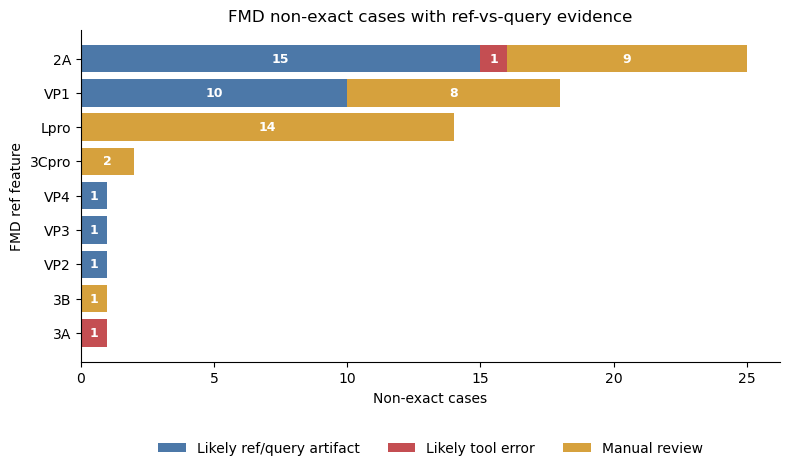

In [26]:
if not fmd_failures.empty:
    fmd_bucket = (
        fmd_failures.groupby(['ref_name', 'fmd_bucket'])
        .size()
        .reset_index(name='cases')
    )
    feature_order = (
        fmd_failures.groupby('ref_name')
        .size()
        .sort_values(ascending=True)
        .index
    )
    bucket_order = ['likely_validation_artifact', 'likely_tool_error', 'manual_review']
    plot_df = (
        fmd_bucket.pivot_table(index='ref_name', columns='fmd_bucket', values='cases', fill_value=0)
        .reindex(index=feature_order, columns=bucket_order, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(8, max(3.2, 0.42 * len(plot_df) + 1.2)))
    left = pd.Series(0, index=plot_df.index, dtype=float)
    label_map = {
        'likely_validation_artifact': 'Likely ref/query artifact',
        'likely_tool_error': 'Likely tool error',
        'manual_review': 'Manual review',
    }
    for bucket in bucket_order:
        vals = plot_df[bucket]
        bars = ax.barh(plot_df.index, vals, left=left, color=BUCKET_COLORS[bucket], label=label_map[bucket])
        for bar, value, start in zip(bars, vals, left):
            if value > 0:
                ax.text(start + value / 2, bar.get_y() + bar.get_height() / 2, str(int(value)),
                        ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        left += vals

    ax.set_xlabel('Non-exact cases')
    ax.set_ylabel('FMD ref feature')
    ax.set_title('FMD non-exact cases with ref-vs-query evidence')
    ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.32), frameon=False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'fmd_failure_breakdown.png', dpi=180, bbox_inches='tight')


### FMD Case Table

This is the compact manual-review table. The most important columns are `ref_len`, `pred_len`, `truth_len`, and their deltas.

In [27]:
fmd_failure_cases = fmd_failures[case_cols].sort_values(['ref_name', 'record_id']) if not fmd_failures.empty else pd.DataFrame()
fmd_failure_cases.to_csv(OUTPUT_DIR / 'fmd_failure_cases.tsv', sep='	', index=False)
fmd_failure_cases.head(60)

,record_id,ref_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,pred_minus_truth_len,...,delta_end,failure_mode,status,coverage,identity,iou,best_iou,fmd_length_bucket,fmd_bucket,fmd_evidence_note
1,AY687333.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...
5,AY687334.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...
14,DQ533483.2,2A,2A,2A,54,51.0,54.0,-3.0,0.0,-3.0,...,0.0,Boundary offset,ok,0.9444,94.1,0.9444,0.9444,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...
6,DQ989304.1,2A,2A,2A,54,51.0,54.0,-3.0,0.0,-3.0,...,0.0,Boundary offset,ok,0.9444,94.1,0.9444,0.9444,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...
7,DQ989313.1,2A,2A,2A,54,51.0,54.0,-3.0,0.0,-3.0,...,0.0,Boundary offset,ok,0.9444,100.0,0.9444,0.9444,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...
12,FJ175666.1,2A,2A,None,54,NaN,54.0,NaN,0.0,NaN,...,NaN,Not lifted,no_hit,0.0000,NaN,0.0000,0.0000,not_lifted,likely_tool_error,tblastn found no usable hit for this reference...
13,GU931682.1,2A,2A,2A,54,51.0,54.0,-3.0,0.0,-3.0,...,0.0,Boundary offset,ok,0.9444,100.0,0.9444,0.9444,prediction_differs_ref_and_truth,manual_review,Prediction length matches neither ref nor quer...
17,LC036265.1,2A,2A,2A,54,51.0,48.0,-3.0,-6.0,3.0,...,0.0,Boundary offset,ok,0.9444,100.0,0.9412,0.9412,boundary_shift_mixed_length,manual_review,Mixed evidence; manual review needed.
21,MG372727.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,94.4,0.8889,0.8889,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...
23,MG372728.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,100.0,0.8889,0.8889,prediction_matches_ref_query_truth_differs,likely_validation_artifact,Prediction length matches ref; query truth use...


### FMD Final Adjudication

This converts the ref-aware evidence into concrete final causes. Here `tool` includes both severe misses and strict boundary errors. Boundary errors are separated into minor vs major causes below.

In [ ]:
def _fmd_final_reason(row):
    feature = row['ref_name']
    bucket = row.get('fmd_length_bucket')
    mode = row.get('failure_mode')
    ds = row.get('delta_start')
    de = row.get('delta_end')

    if bucket == 'truth_absent':
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'truth_feature_absent',
            'final_explanation': 'Query truth lacks the same-name feature, so the prediction cannot be scored against this truth set.',
        })
    if bucket == 'prediction_matches_ref_query_truth_differs':
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'ref_query_boundary_convention_mismatch',
            'final_explanation': 'Prediction length matches the reference feature, but query truth uses a different feature boundary.',
        })
    if mode == 'Not lifted':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'no_hit',
            'final_explanation': 'The feature exists in truth but tblastn did not produce a usable hit.',
        })
    if feature == '3A' and ds == 0 and de == -111:
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'major_c_terminal_truncation',
            'final_explanation': 'Start matches truth, but prediction ends 111 bp early and matches neither ref nor truth length.',
        })
    if feature in {'Lpro', '3Cpro'} and ds == 12 and de == 0:
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'n_terminal_truncation_12bp',
            'final_explanation': 'Ref and truth lengths agree, but prediction starts 12 bp downstream, truncating the N-terminus by 4 aa.',
        })
    if feature == '2A' and mode == 'Boundary offset':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'short_peptide_boundary_offset',
            'final_explanation': 'Prediction differs from ref/truth by 3 bp in a very short peptide; small boundary error is amplified by IoU.',
        })
    if feature == '3B' and de == -3:
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'minor_c_terminal_truncation_3bp',
            'final_explanation': 'Prediction ends 3 bp before ref/truth, a one-codon C-terminal truncation.',
        })
    if feature == 'VP1':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'minor_vp1_boundary_offset',
            'final_explanation': 'Prediction does not match both ref and truth boundary; offset is small and IoU remains high, but it is tool-side under strict scoring.',
        })
    return pd.Series({
        'final_blame': 'tool',
        'final_cause': 'boundary_offset_matches_neither_ref_nor_truth',
        'final_explanation': 'Prediction boundary matches neither ref nor query truth under strict comparison.',
    })

if fmd_failures.empty:
    fmd_final = pd.DataFrame()
else:
    final_cols = fmd_failures.apply(_fmd_final_reason, axis=1)
    fmd_final = pd.concat([fmd_failures, final_cols], axis=1)

fmd_final.to_csv(OUTPUT_DIR / 'fmd_failure_final_adjudication.tsv', sep='	', index=False)

fmd_final_blame_summary = (
    fmd_final.groupby('final_blame')
    .size()
    .reset_index(name='cases')
    if not fmd_final.empty else pd.DataFrame(columns=['final_blame', 'cases'])
)
if not fmd_final_blame_summary.empty:
    fmd_final_blame_summary['pct_of_failures'] = (fmd_final_blame_summary['cases'] / len(fmd_final) * 100).round(2)
    fmd_final_blame_summary['pct_of_all_predictions'] = (fmd_final_blame_summary['cases'] / raw_accuracy.loc[raw_accuracy['virus'] == 'FMD', 'total'].iloc[0] * 100).round(2)

fmd_final_blame_summary.to_csv(OUTPUT_DIR / 'fmd_failure_final_blame_summary.tsv', sep='	', index=False)
fmd_final_blame_summary

In [ ]:
fmd_final_summary = (
    fmd_final.groupby(['final_blame', 'final_cause'])
    .size()
    .reset_index(name='cases')
    if not fmd_final.empty else pd.DataFrame(columns=['final_blame', 'final_cause', 'cases'])
)
if not fmd_final_summary.empty:
    total_fmd = raw_accuracy.loc[raw_accuracy['virus'] == 'FMD', 'total'].iloc[0]
    fmd_final_summary['pct_of_failures'] = (fmd_final_summary['cases'] / len(fmd_final) * 100).round(2)
    fmd_final_summary['pct_of_all_predictions'] = (fmd_final_summary['cases'] / total_fmd * 100).round(2)
    fmd_final_summary = fmd_final_summary.sort_values(['final_blame', 'cases'], ascending=[True, False])

fmd_final_summary.to_csv(OUTPUT_DIR / 'fmd_failure_final_summary.tsv', sep='	', index=False)
fmd_final_summary